<a href="https://colab.research.google.com/github/Damian177/data_sc_prac/blob/main/Fitting%20Linear%20models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Module 2: Fitting the Linear Model

### Step 0

Load the appropriate libraries and bring in the data. Note that we have to run a script to get the [California Housing dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) to match as it is in scikit-learn. We cannot pull it directly from scikit-learn since CodeGrade cannot access the internet.

In [4]:
# CodeGrade step0

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import os
import tarfile
import joblib # Import joblib directly
from sklearn.datasets._base import _pkl_filepath, get_data_home
import statsmodels.api as sm


archive_path = "cal_housing.tgz" # change the path if it's not in the current directory
data_home = get_data_home(data_home=None) # change data_home if you are not using ~/scikit_learn_data
if not os.path.exists(data_home):
    os.makedirs(data_home)
filepath = _pkl_filepath(data_home, 'cal_housing.pkz')

with tarfile.open(mode="r:gz", name=archive_path) as f:
    cal_housing = np.loadtxt(
        f.extractfile('CaliforniaHousing/cal_housing.data'),
        delimiter=',')
    # Columns are not in the same order compared to the previous
    # URL resource on lib.stat.cmu.edu
    columns_index = [8, 7, 2, 3, 4, 5, 6, 1, 0]
    cal_housing = cal_housing[:, columns_index]

    joblib.dump(cal_housing, filepath, compress=6) # Now using the directly imported joblib

# Load the dataset
california = fetch_california_housing(as_frame=True)
data = california.data
target = california.target

### Step 1

*   Create a copy of the data and call it `df`
*   Select the `X` variable to be `MedInc` and the `y` be `MedianHouseValue`

Return `X.shape, y.shape` to verify.

In [5]:
# CodeGrade step1

# Create a copy of the data
df = data.copy()

# Select X (MedInc) and y (MedianHouseValue)
X = df[['MedInc']]   # DataFrame with one column
y = target           # Series or array

# Return shapes to verify
X.shape, y.shape

((20640, 1), (20640,))

### Step 2

Using `statsmodels`


*   Add the constant term and call it `X_const`
*   fit the OLS model and call it `model`
*   extract the residuals and call them `residuals`
*   count the number of positive and negative residuals, calling them `positive_residuals` and `negative_residuals`, respectively

Return `positive_residuals, negative_residuals` to verify.

In [6]:
# CodeGrade step2

# Add constant term
X_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Extract residuals
residuals = model.resid

# Count positive and negative residuals
positive_residuals = (residuals > 0).sum()
negative_residuals = (residuals < 0).sum()

positive_residuals, negative_residuals

(np.int64(8375), np.int64(12265))

### Code

Compute and return $r^2$, calling it `r_squared`.

In [7]:
# CodeGrade step3

# Compute R-squared
r_squared = model.rsquared
r_squared

np.float64(0.47344749180719903)

Plot the residual plot.

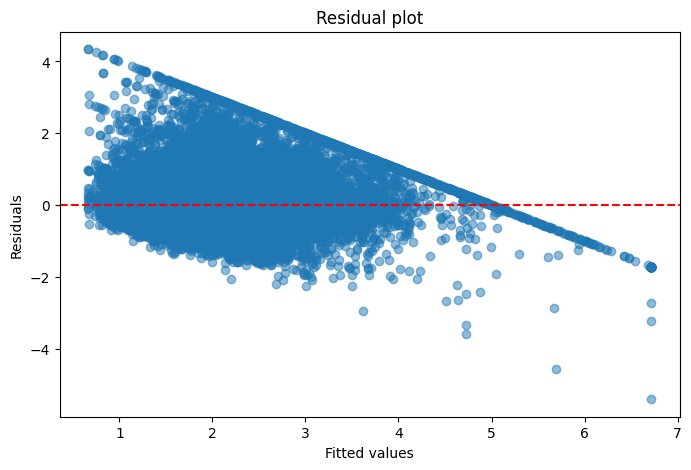

In [8]:
# Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(model.fittedvalues, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual plot')
plt.show()

### Step 4

Compute Cook's distance, where the model's `get_influence` is called `influence` and the Cook's distance from this is called `cooks_d`.

Then identify the influential points, calling them `influential_points`. Verify this by returing `influential_points.shape`.

In [9]:
# CodeGrade step4

# Get influence and Cook's distance
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

# Identify influential points using threshold 4/n
n = len(cooks_d)
threshold = 4 / n
influential_points = np.where(cooks_d > threshold)[0]

# Verify shape
influential_points.shape

(1230,)

Now plot Cook's Distance.

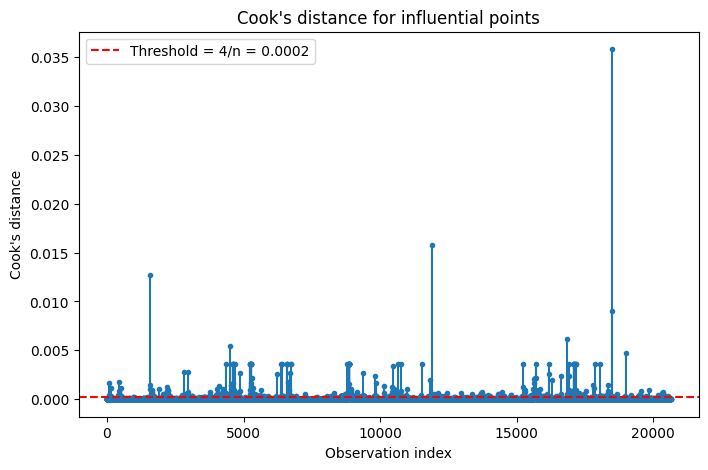

In [10]:
# Plot Cook's Distance
plt.figure(figsize=(8, 5))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt='.', basefmt=' ')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = 4/n = {threshold:.4f}')
plt.xlabel('Observation index')
plt.ylabel("Cook's distance")
plt.title("Cook's distance for influential points")
plt.legend()
plt.show()